In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Project Finance.xlsx to Project Finance.xlsx


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
df = pd.read_excel('Project Finance.xlsx', sheet_name='Forecasting')
df.dtypes
df.head(20)

,Forecasting,Monthly Revenue
0,2013-09-01,6.117184e+06
1,2013-10-01,1.118875e+07
2,2013-11-01,7.630027e+06
3,2013-12-01,6.497387e+06
4,2014-01-01,8.236148e+06
5,2014-02-01,7.837280e+06
6,2014-03-01,6.131979e+06
7,2014-04-01,9.126710e+06
8,2014-05-01,6.483236e+06
9,2014-06-01,1.330262e+07


In [ ]:
kolom_tanggal = 'Forecasting'
kolom_target = 'Monthly Revenue'

In [ ]:
df[kolom_tanggal] = pd.to_datetime(df[kolom_tanggal])
df.set_index(kolom_tanggal, inplace=True)

In [ ]:
df.head()

,Monthly Revenue
Forecasting,
2013-09-01,6.117184e+06
2013-10-01,1.118875e+07
2013-11-01,7.630027e+06
2013-12-01,6.497387e+06
2014-01-01,8.236148e+06


In [ ]:
df = df.asfreq('MS')
df['Monthly Revenue'] = df['Monthly Revenue'].ffill()
df.head()

,Monthly Revenue
Forecasting,
2013-09-01,6.117184e+06
2013-10-01,1.118875e+07
2013-11-01,7.630027e+06
2013-12-01,6.497387e+06
2014-01-01,8.236148e+06


In [ ]:
df_awal = pd.read_excel('Project Finance.xlsx', sheet_name='Forecasting')
print(df_awal.columns.tolist())

['Forecasting', 'Monthly Revenue']


In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 11.1 MB/s eta 0:00:00


In [ ]:
import pmdarima as pm

In [ ]:
model_otomatis = pm.auto_arima(
    df[kolom_target],
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    seasonal=False,
    m=12,
    d=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
)

print(model_otomatis.summary())

/usr/local/lib/python3.13/dist-packages/pmdarima/arima/_validation.py:62: UserWarning: m (12) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=558.950, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=536.791, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=554.824, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=528.005, Time=0.05 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=525.447, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=527.769, Time=0.06 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=527.447, Time=0.06 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=525.826, Time=0.10 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=531.964, Time=0.05 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=527.253, Time=0.16 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=519.240, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=517.315, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=516.652, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=518.343, 

In [ ]:
ts_data = df[kolom_target]

In [ ]:
model = ARIMA(ts_data, order=(1, 0, 0))
model_fitted = model.fit()

In [ ]:
langkah_prediksi = 12
forecast_resault = model_fitted.forecast(steps=langkah_prediksi)
print(forecast_resault)

2015-01-01    6.866204e+06
2015-02-01    9.310282e+06
2015-03-01    7.980957e+06
2015-04-01    8.703972e+06
2015-05-01    8.310727e+06
2015-06-01    8.524611e+06
2015-07-01    8.408280e+06
2015-08-01    8.471552e+06
2015-09-01    8.437139e+06
2015-10-01    8.455856e+06
2015-11-01    8.445676e+06
2015-12-01    8.451213e+06
Freq: MS, Name: predicted_mean, dtype: float64


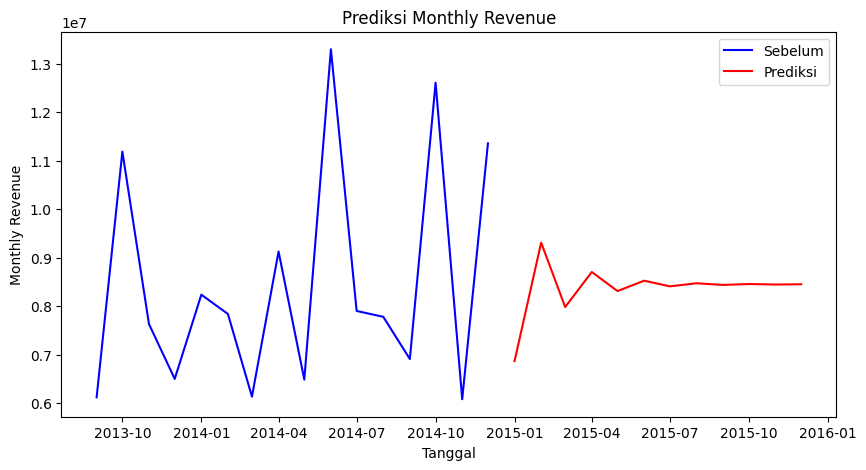

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(ts_data, label='Sebelum', color='blue')
plt.plot(forecast_resault, label='Prediksi', color='red')
plt.xlabel('Tanggal')
plt.ylabel('Monthly Revenue')
plt.title('Prediksi Monthly Revenue')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
jumlah_uji = 12
data_train = ts_data.iloc[:-jumlah_uji]
data_test = ts_data.iloc[-jumlah_uji:]

In [ ]:
model_uji = pm.auto_arima(data_train, seasonal=False, m=12, stepwise=True)

/usr/local/lib/python3.13/dist-packages/pmdarima/arima/_validation.py:62: UserWarning: m (12) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


In [ ]:
prediksi_test = model_uji.predict(n_periods=jumlah_uji)

In [ ]:
mae_test = mean_absolute_error(data_test, prediksi_test)
rmse_test = np.sqrt(mean_squared_error(data_test, prediksi_test))
mape_test = np.mean(np.abs((data_test - prediksi_test) / data_test)) * 100

print(f'MAE: {mae_test:.2f}')
print(f'RMSE: {rmse_test:.2f}')
print(f'MAPE: {mape_test:.2f}%')

MAE: 1776559.42
RMSE: 2503296.35
MAPE: 18.51%


In [ ]:
confidence_intervals = forecast_resault.conf_int()

In [ ]:
print(confidence_intervals)

            lower Monthly Revenue  upper Monthly Revenue
2015-01-01           3.032880e+06           1.069953e+07
2015-02-01           4.946648e+06           1.367392e+07
2015-03-01           3.472385e+06           1.248953e+07
2015-04-01           4.153408e+06           1.325454e+07
2015-05-01           3.747815e+06           1.287364e+07
2015-06-01           3.958053e+06           1.309117e+07
2015-07-01           3.840644e+06           1.297592e+07
2015-08-01           3.903597e+06           1.303951e+07
2015-09-01           3.869090e+06           1.300519e+07
2015-10-01           3.887779e+06           1.302393e+07
2015-11-01           3.877591e+06           1.301376e+07
2015-12-01           3.883125e+06           1.301930e+07


In [ ]:
df_hasil = pd.DataFrame({
    'Prediksi': forecast_resault,
    'Lower': confidence_intervals['lower Monthly Revenue'],
    'Upper': confidence_intervals['upper Monthly Revenue']
})

In [ ]:
df_hasil.to_excel('hasil_arima.xlsx', index=True)

In [ ]:
forecast_resault.to_excel('arima.xlsx', index=True)